## Importar bibliotecas e matplotlib


In [ ]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
from scipy.stats import t as t_dist
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch



# Configuração do matplotlib
warnings.filterwarnings('default')
plt.switch_backend('Agg')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


# Carregamento dos dados

In [97]:
df = pd.read_csv('processed_lisboa_porto_air_quality.csv', sep=';')

# EDA


In [98]:
df.head()

,city,datetime,CO,NO2,O3,PM10,PM2.5,SO2,temperature_c,humidity_percent,pressure_hpa,wind_speed_kmh,wind_direction_deg,precipitation_mm,C6H6,NMHC,NOx,air_quality_good,year,month
0,Lisboa,05/09/25 01:00,0.96,25.20,84.09,11.82,9.12,6.75,18.9,82.0,1018.5,16.2,357.0,0.0,NaN,NaN,NaN,True,2025,9
1,Lisboa,05/09/25 02:00,0.75,26.40,86.20,13.24,8.87,5.11,18.8,80.0,1018.3,15.5,356.0,0.0,NaN,NaN,NaN,True,2025,9
2,Lisboa,05/09/25 03:00,0.87,25.16,74.41,15.18,10.84,5.76,18.6,79.0,1017.4,11.5,2.0,0.0,NaN,NaN,NaN,True,2025,9
3,Lisboa,05/09/25 04:00,0.51,13.59,68.57,17.48,13.14,5.03,18.3,77.0,1017.2,11.3,351.0,0.0,NaN,NaN,NaN,True,2025,9
4,Lisboa,05/09/25 05:00,0.61,15.89,78.79,14.70,13.68,6.20,18.6,72.0,1016.8,9.4,356.0,0.0,NaN,NaN,NaN,True,2025,9


O dataset contém várias variáveis relacionadas com a qualidade do ar, incluindo poluentes (NO2, CO, PM10, etc.) e variáveis meteorológicas (temperatura, humidade, vento, etc.).

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10768 entries, 0 to 10767
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                10768 non-null  str    
 1   datetime            10768 non-null  str    
 2   CO                  9116 non-null   float64
 3   NO2                 9157 non-null   float64
 4   O3                  1442 non-null   float64
 5   PM10                1442 non-null   float64
 6   PM2.5               1442 non-null   float64
 7   SO2                 1442 non-null   float64
 8   temperature_c       10433 non-null  float64
 9   humidity_percent    10433 non-null  float64
 10  pressure_hpa        1442 non-null   float64
 11  wind_speed_kmh      1442 non-null   float64
 12  wind_direction_deg  1442 non-null   float64
 13  precipitation_mm    1442 non-null   float64
 14  C6H6                8991 non-null   float64
 15  NMHC                914 non-null    float64
 16  NOx            

A análise da estrutura do dataset revelou a existência de 10768 observações e 20 variáveis. No entanto, verificou-se que algumas variáveis apresentam um número significativo de valores em falta, nomeadamente O3, PM10, PM2.5 e SO2, que possuem apenas cerca de 1442 observações válidas.
Por outro lado, variáveis como NO2, CO, temperatura e humidade apresentam maior completude, sendo mais adequadas para utilização nos modelos.
Esta diferença na qualidade dos dados pode influenciar a escolha das variáveis e a construção dos modelos de machine learning.

<Figure size 1200x600 with 0 Axes>

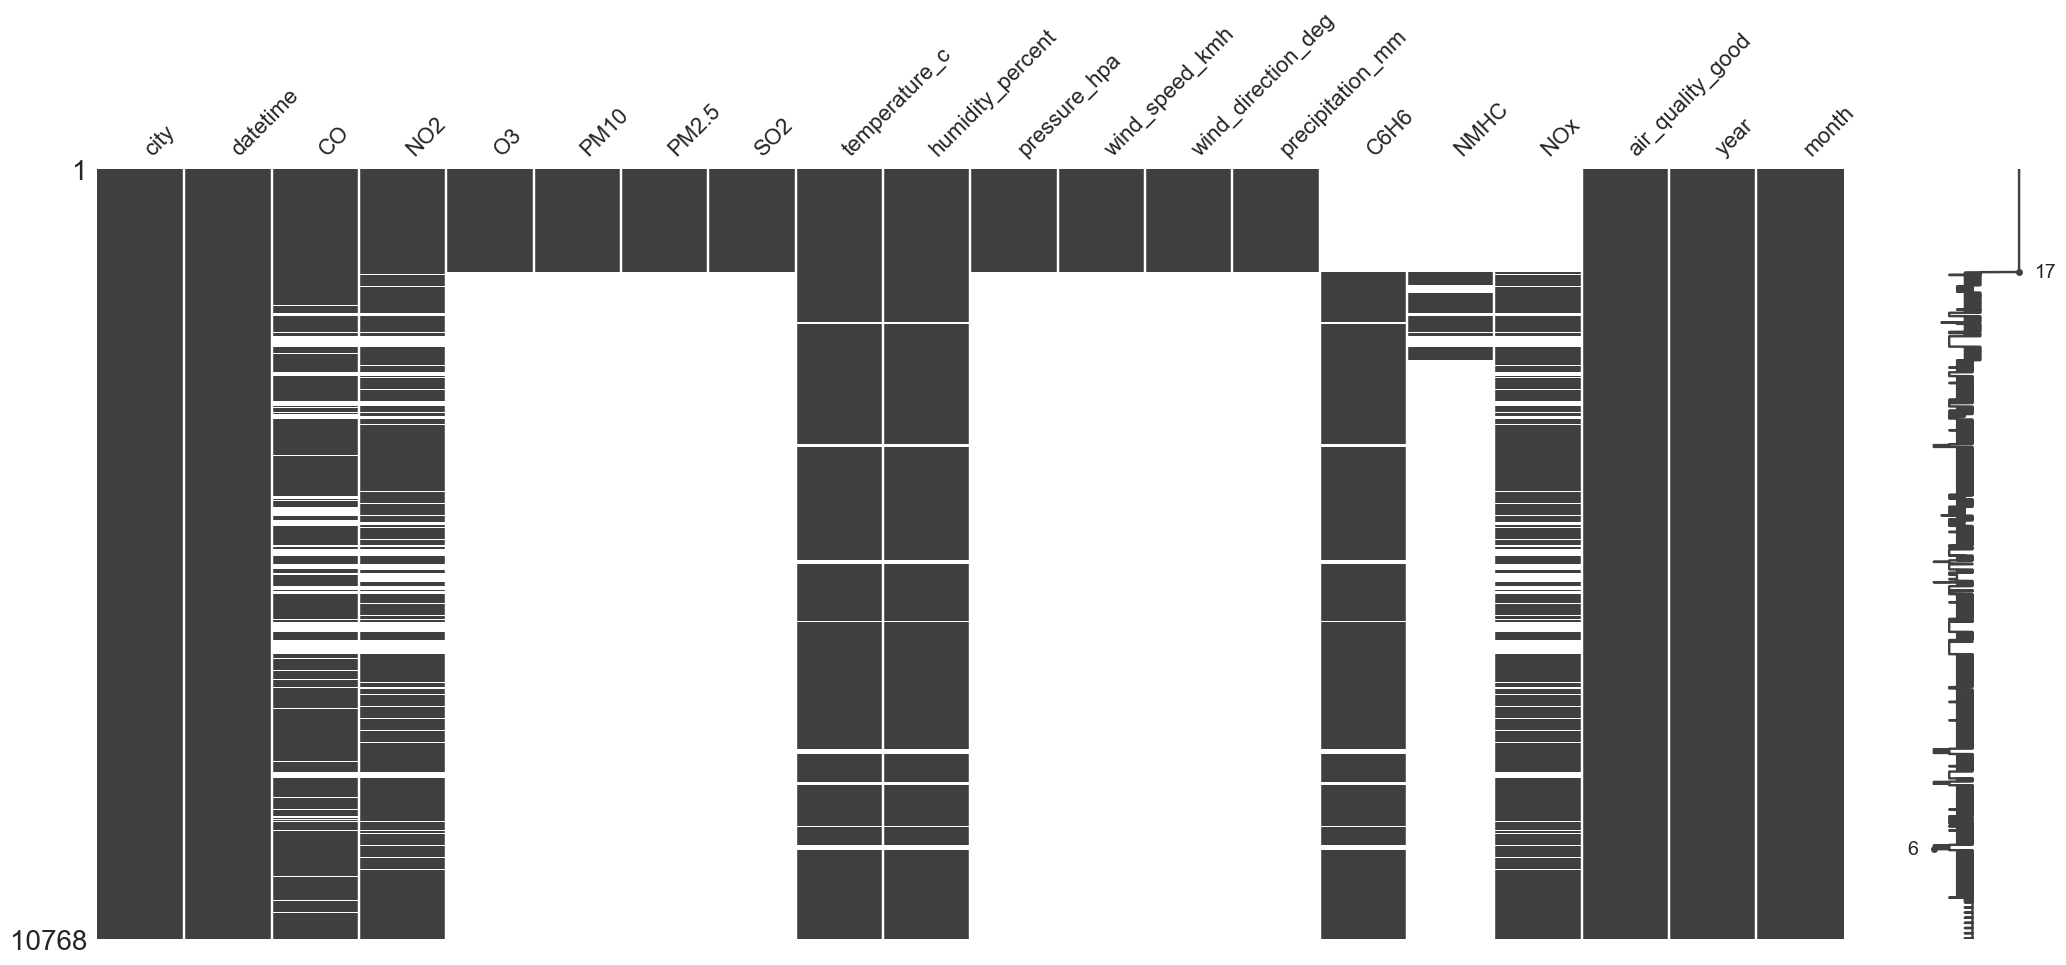

In [100]:
%matplotlib inline
import pandas as pd 
import missingno as msno 
import matplotlib.pyplot as plt
# Tamanho do gráfico 
plt.figure(figsize=(12,6))

# Matriz de valores vazios
msno.matrix (df)
plt.show ()

A matriz de valores em falta permite identificar a distribuição dos dados ausentes ao longo das variáveis e das observações. Verifica-se que algumas variáveis, como O3, PM10, PM2.5 e SO2, apresentam grandes blocos de valores em falta, indicando uma cobertura temporal reduzida. Por outro lado, variáveis como temperatura, humidade e CO apresentam maior disponibilidade de dados. Este padrão sugere que a qualidade dos dados varia de forma significativa entre variáveis, podendo influenciar a selecção das variáveis e exigir estratégias de tratamento de valores em falta antes da modelação.

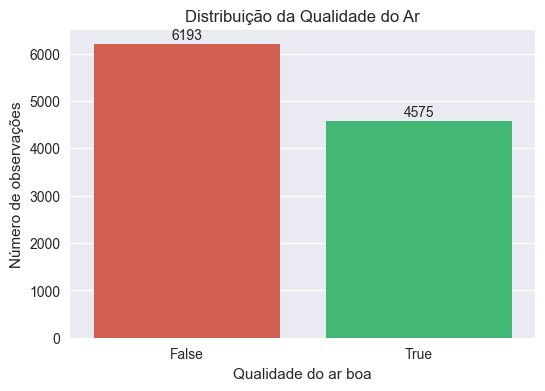

In [101]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='air_quality_good',
    hue='air_quality_good',
    data=df,
    palette={False: "#e74c3c", True: "#2ecc71"},
    legend=False
)

plt.title("Distribuição da Qualidade do Ar")
plt.xlabel("Qualidade do ar boa")
plt.ylabel("Número de observações")

for i, v in enumerate(df['air_quality_good'].value_counts().sort_index()):
    plt.text(i, v + 100, str(v), ha='center')

plt.show()

A variável alvo apresenta algum desequilíbrio entre classes: 6193 observações correspondem a má qualidade do ar (False), cerca de 57.5%, enquanto 4575 correspondem a boa qualidade do ar (True), cerca de 42.5%.
Apesar deste desequilíbrio, as classes não estão extremamente desbalanceadas, pelo que a variável alvo é adequada para treinar modelos de classificação.

In [102]:
df.isnull().sum().sort_values(ascending=False)

NMHC                  9854
pressure_hpa          9326
wind_speed_kmh        9326
precipitation_mm      9326
O3                    9326
PM10                  9326
PM2.5                 9326
SO2                   9326
wind_direction_deg    9326
NOx                   3050
C6H6                  1777
CO                    1652
NO2                   1611
humidity_percent       335
temperature_c          335
year                     0
air_quality_good         0
city                     0
datetime                 0
month                    0
dtype: int64

A análise dos valores em falta revelou que várias variáveis apresentam uma quantidade significativa de dados ausentes. Em particular, variáveis como PM10, O3, PM2.5 e SO2 apresentam mais de 9000 valores em falta, o que representa a maioria do dataset.
Por outro lado, variáveis como temperatura e humidade apresentam poucos valores em falta, sendo mais adequadas para utilização nos modelos.
Esta diferença na qualidade dos dados implica decisões importantes no pré-processamento, nomeadamente entre remover observações incompletas ou imputar valores em falta.

In [103]:
(df.isnull().sum() / len(df)) * 100

city                   0.00
datetime               0.00
CO                    15.34
NO2                   14.96
O3                    86.61
PM10                  86.61
PM2.5                 86.61
SO2                   86.61
temperature_c          3.11
humidity_percent       3.11
pressure_hpa          86.61
wind_speed_kmh        86.61
wind_direction_deg    86.61
precipitation_mm      86.61
C6H6                  16.50
NMHC                  91.51
NOx                   28.32
air_quality_good       0.00
year                   0.00
month                  0.00
dtype: float64

A análise da percentagem de valores em falta revelou que várias variáveis apresentam uma elevada proporção de dados ausentes. Em particular, variáveis como O3, PM10, PM2.5 e SO2 apresentam cerca de 86% de valores em falta, enquanto a variável NMHC apresenta mais de 90%.
Por outro lado, variáveis como temperatura e humidade apresentam menos de 5% de valores em falta, sendo mais fiáveis para utilização nos modelos.
Estas diferenças indicam a necessidade de selecionar cuidadosamente as variáveis, podendo optar por remover variáveis com muitos valores em falta ou aplicar técnicas de imputação.


## Estatísticas Descritivas 

In [104]:
df.describe()

,CO,NO2,O3,PM10,PM2.5,SO2,temperature_c,humidity_percent,pressure_hpa,wind_speed_kmh,wind_direction_deg,precipitation_mm,C6H6,NMHC,NOx,year,month
count,9116.00,9157.00,1442.00,1442.00,1442.00,1442.00,10433.00,10433.00,1442.00,1442.00,1442.00,1442.00,8991.00,914.00,7718.00,10768.00,10768.00
mean,1.97,99.96,69.30,21.61,15.14,6.45,18.47,51.98,1019.59,8.95,234.53,0.04,10.08,218.81,246.90,2007.02,6.69
std,1.41,54.05,16.78,9.43,6.89,3.05,8.33,18.95,3.06,6.14,122.06,0.57,7.45,204.46,212.98,7.08,3.35
min,0.10,2.00,28.22,1.84,0.10,0.10,-1.90,9.20,1002.90,0.00,1.00,0.00,0.10,7.00,2.00,2004.00,1.00
25%,0.94,57.12,56.55,13.95,9.65,4.12,12.70,37.60,1018.20,3.70,104.00,0.00,4.40,67.00,98.00,2004.00,4.00
50%,1.60,98.00,69.20,20.11,14.08,6.01,18.20,51.70,1020.10,7.30,293.00,0.00,8.20,150.00,180.00,2004.00,7.00
75%,2.60,134.00,81.31,28.02,19.94,8.40,23.80,65.60,1021.60,13.00,340.00,0.00,14.00,297.00,326.00,2005.00,9.00
max,11.90,340.00,114.68,58.57,38.75,18.36,44.60,100.00,1025.70,28.00,360.00,15.60,63.70,1189.00,1479.00,2025.00,12.00


A análise estatística das variáveis numéricas permite observar diferenças significativas na escala e variabilidade dos dados.
Verifica-se que poluentes como NO2 apresentam valores médios elevados (cerca de 99.96), com grande dispersão (desvio padrão de aproximadamente 54), indicando elevada variabilidade ao longo do tempo.
Por outro lado, variáveis como CO apresentam valores médios mais baixos, sugerindo concentrações relativamente reduzidas.
Observa-se também uma grande diferença entre os valores mínimos e máximos em várias variáveis, como NO2 e C6H6, o que pode indicar a presença de valores extremos (outliers).
Relativamente às variáveis meteorológicas, a temperatura apresenta valores entre aproximadamente -1.9°C e 44.6°C, enquanto a humidade varia entre cerca de 9% e 100%, refletindo condições ambientais diversas.
Estas diferenças evidenciam a heterogeneidade do dataset e reforçam a necessidade de uma análise mais detalhada da distribuição das variáveis.

Adicionalmente, verifica-se que o número de observações (count) varia entre variáveis, refletindo a presença de valores em falta identificada anteriormente.

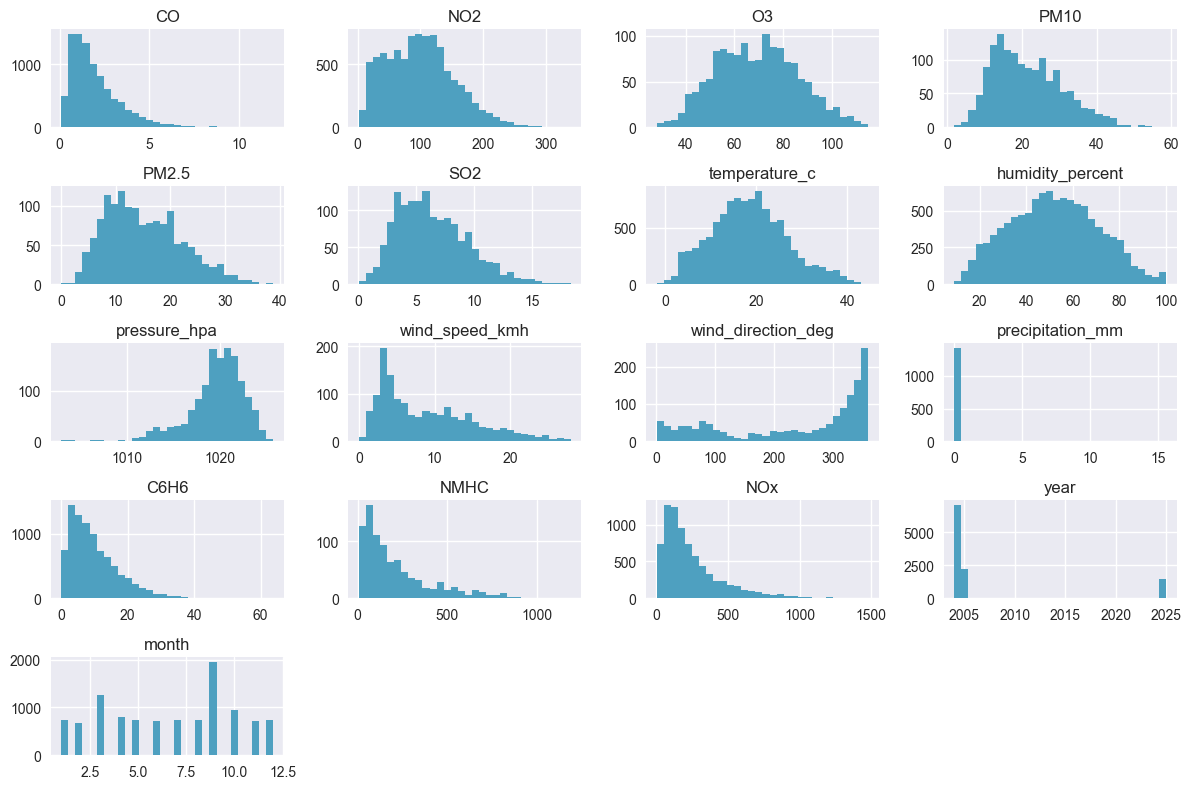

In [105]:
%matplotlib inline

df.hist(figsize=(12,8), bins=30, color="#4EA0C0") 
plt.tight_layout()
plt.show()

Os histogramas mostram que várias variáveis apresentam distribuições assimétricas, especialmente CO, C6H6, NMHC e NOx, com concentração de valores baixos e alguns valores elevados, sugerindo a presença de outliers.
A variável NO2 apresenta elevada variabilidade, enquanto temperatura e humidade têm distribuições mais equilibradas.
A precipitação concentra-se maioritariamente em valores próximos de zero, indicando poucos períodos de chuva.

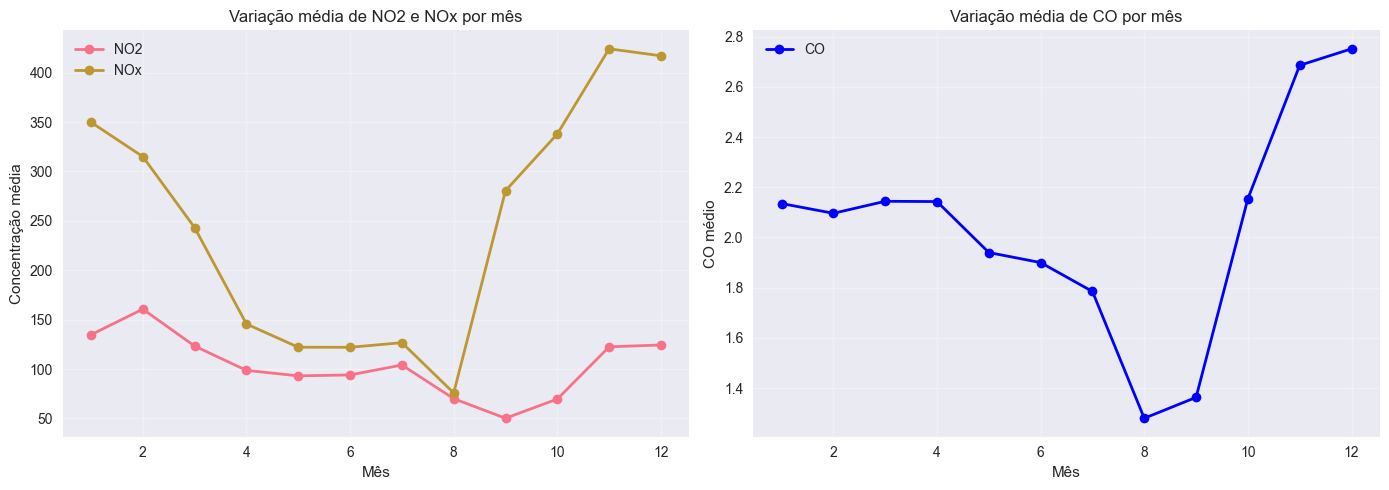

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# NO2 e NOx juntos
for col in ['NO2', 'NOx']:
    df.groupby('month')[col].mean().plot(
        ax=axes[0],
        marker='o',
        linewidth=2,
        label=col
    )

axes[0].set_title("Variação média de NO2 e NOx por mês")
axes[0].set_xlabel("Mês")
axes[0].set_ylabel("Concentração média")
axes[0].grid(alpha=0.3)
axes[0].legend()

# CO separado
df.groupby('month')['CO'].mean().plot(
    ax=axes[1],
    marker='o',
    linewidth=2,
    color='blue',
    label='CO'
)

axes[1].set_title("Variação média de CO por mês")
axes[1].set_xlabel("Mês")
axes[1].set_ylabel("CO médio")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

A análise temporal revela padrões sazonais nos poluentes. Observa-se que NO2 e NOx apresentam valores mais elevados nos meses de inverno (início e final do ano) e reduzem durante os meses de verão, sugerindo influência de fatores como condições meteorológicas e menor dispersão atmosférica no inverno.
Por outro lado, o CO apresenta variações menos acentuadas, embora também evidencie uma ligeira redução nos meses de verão e aumento nos meses finais do ano.
Estes padrões sazonais indicam que a variável temporal (mês) pode ser relevante para a modelação da qualidade do ar.

<Figure size 1000x500 with 0 Axes>

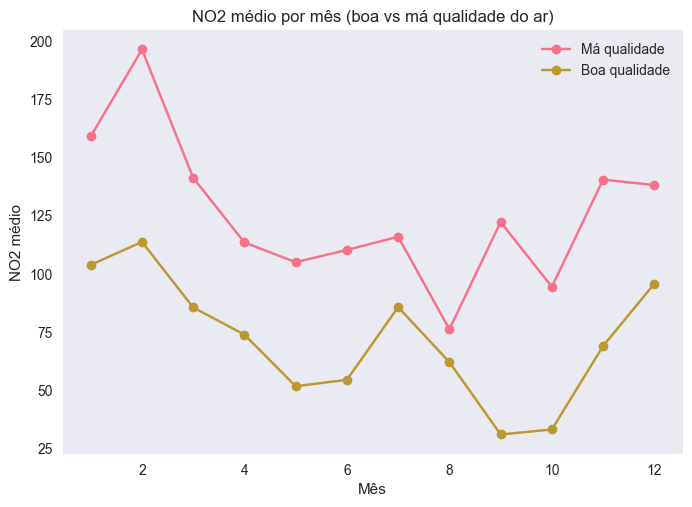

In [107]:
plt.figure(figsize=(10,5))

df.groupby(['month', 'air_quality_good'])['NO2'].mean().unstack().plot(marker='o')

plt.title("NO2 médio por mês (boa vs má qualidade do ar)")
plt.xlabel("Mês")
plt.ylabel("NO2 médio")
plt.legend(["Má qualidade", "Boa qualidade"])
plt.grid()

plt.show()

Observa-se que, ao longo de todos os meses, os valores médios de NO2 são consistentemente mais elevados quando a qualidade do ar é má (air_quality_good = False).

Verifica-se também um padrão sazonal, com concentrações mais elevadas nos meses de inverno (início e final do ano) e valores mais baixos no verão. Esta diferença é mais acentuada na classe de má qualidade do ar, sugerindo que o NO2 é um forte indicador da degradação da qualidade do ar.

Estes resultados indicam que tanto a variável temporal (mês) como a concentração de NO2 podem ser relevantes para a modelação da qualidade do ar.

<Figure size 1000x500 with 0 Axes>

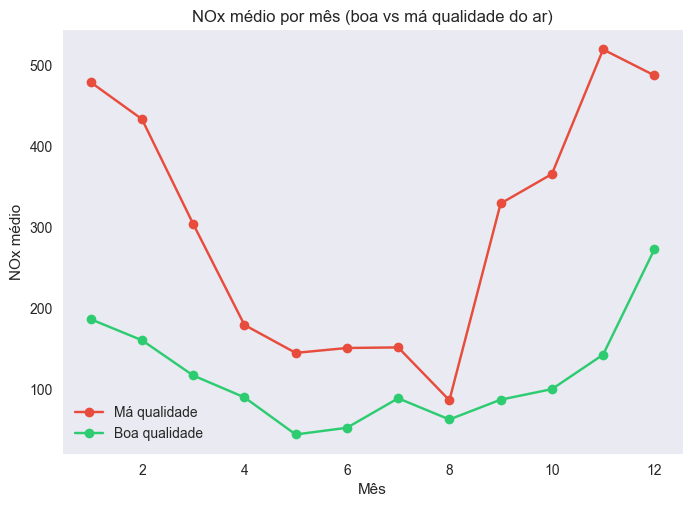

In [108]:
plt.figure(figsize=(10,5))

df.groupby(['month', 'air_quality_good'])['NOx'].mean().unstack().plot(
    marker='o',
    color=['#e74c3c', '#2ecc71']
)

plt.title("NOx médio por mês (boa vs má qualidade do ar)")
plt.xlabel("Mês")
plt.ylabel("NOx médio")
plt.legend(["Má qualidade", "Boa qualidade"])
plt.grid()

plt.show()

Tal como observado para o NO2, os níveis médios de NOx são consistentemente mais elevados nos períodos classificados como má qualidade do ar.
A diferença entre boa e má qualidade é ainda mais acentuada no NOx, especialmente nos meses de inverno (início e final do ano), onde se observam picos elevados de concentração. Nos meses de verão, os níveis diminuem significativamente em ambas as classes, embora permaneçam superiores na má qualidade.
Este comportamento reforça a forte relação entre NOx e a degradação da qualidade do ar, indicando que este poluente é um dos principais contributos para a classificação de qualidade do ar no dataset.

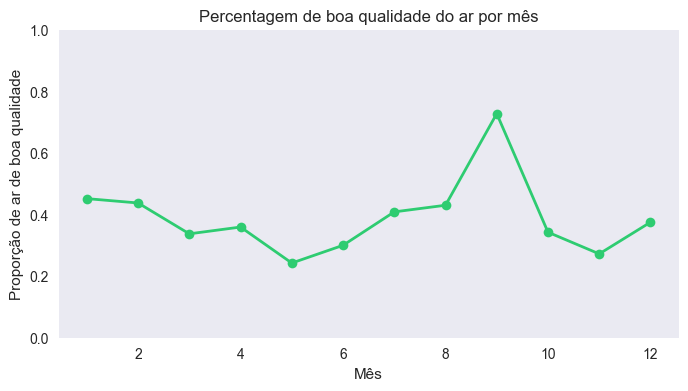

In [109]:
plt.figure(figsize=(8,4))

df.groupby('month')['air_quality_good'].mean().plot(
    marker='o',
    linewidth=2,
    color='#2ecc71'
)

plt.title("Percentagem de boa qualidade do ar por mês")
plt.xlabel("Mês")
plt.ylabel("Proporção de ar de boa qualidade")
plt.ylim(0,1)
plt.grid()

plt.show()

A proporção de dias com boa qualidade do ar varia ao longo dos meses, evidenciando um padrão sazonal. Observa-se um pico significativo no mês 9, indicando melhores condições de qualidade do ar, enquanto outros meses apresentam valores mais baixos.
Este comportamento está alinhado com as variações observadas nos níveis de poluentes, sugerindo uma forte influência de fatores sazonais na qualidade do ar.

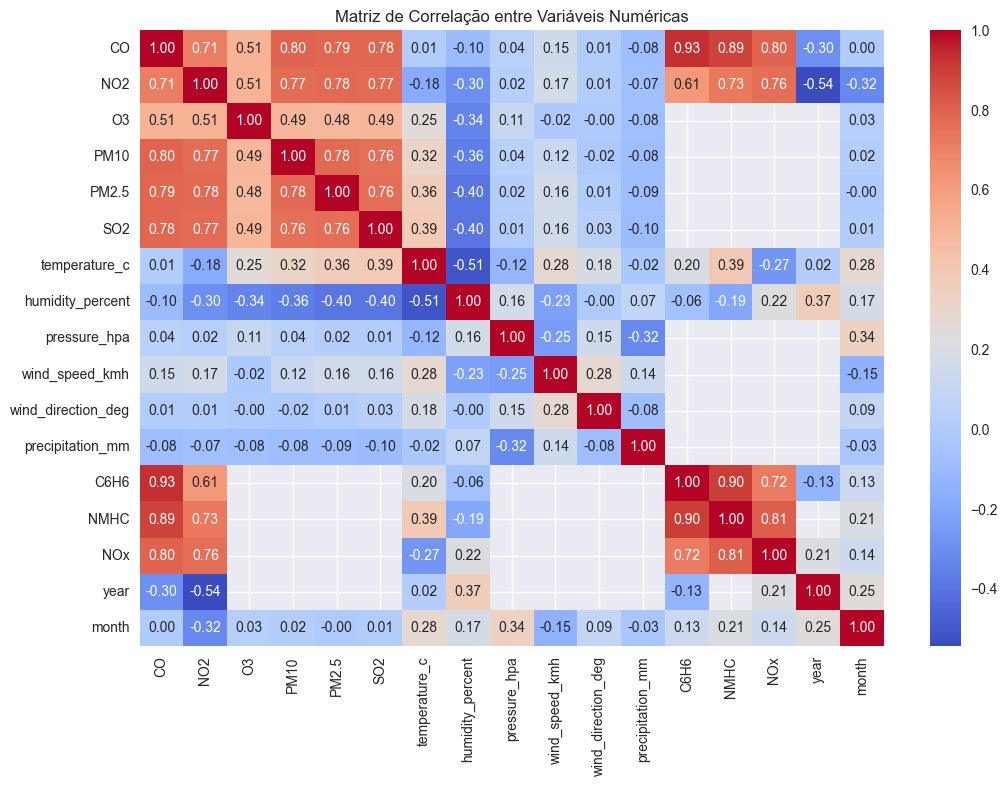

In [110]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Matriz de Correlação entre Variáveis Numéricas")
plt.show()

A matriz de correlação mostra fortes correlações positivas entre vários poluentes, como CO, NO2, PM10, PM2.5 e SO2. Também se observa uma forte relação entre C6H6, NMHC e NOx.
As variáveis meteorológicas apresentam correlações mais fracas com os poluentes, embora a humidade apresente correlações negativas moderadas com algumas variáveis.
Estas relações podem ser relevantes na escolha das variáveis para os modelos, evitando redundância entre variáveis muito correlacionadas.

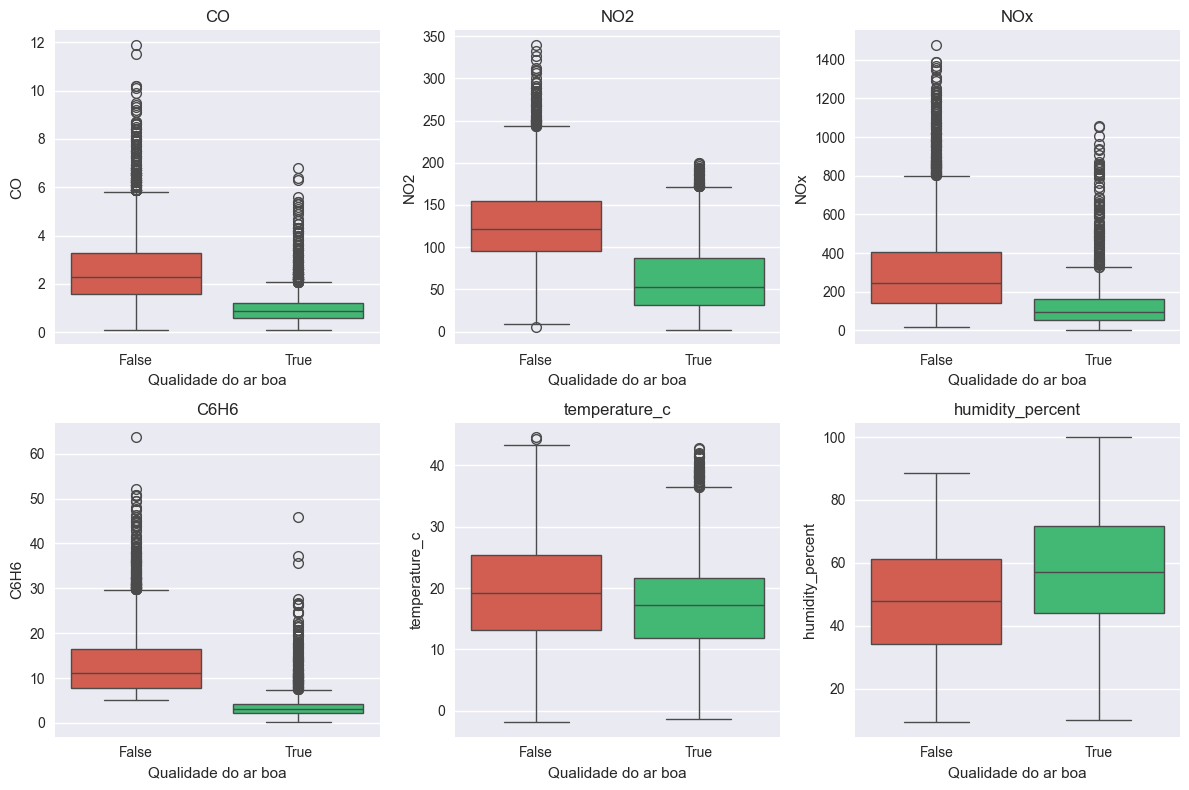

In [111]:
warnings.filterwarnings('ignore')
cols = ['CO', 'NO2', 'NOx', 'C6H6', 'temperature_c', 'humidity_percent']

palette = {
    False: "#e74c3c",  # má qualidade
    True:  "#2ecc71"   # boa qualidade
}

plt.figure(figsize=(12,8))

for i, col in enumerate(cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(
        x='air_quality_good',
        y=col,
        data=df,
        hue='air_quality_good',
        palette=palette,
        legend=False
    )
    plt.title(col)
    plt.xlabel("Qualidade do ar boa")

plt.tight_layout()
plt.show()

A análise dos boxplots mostra diferenças claras entre as classes de qualidade do ar. Variáveis como CO, NO2, NOx e C6H6 apresentam valores mais elevados quando a qualidade do ar é má (air_quality_good = False), sugerindo que estas variáveis são fortes candidatas para prever a qualidade do ar.

Por outro lado, variáveis meteorológicas como temperatura e humidade apresentam diferenças menos acentuadas, sugerindo menor impacto direto na classificação da qualidade do ar.

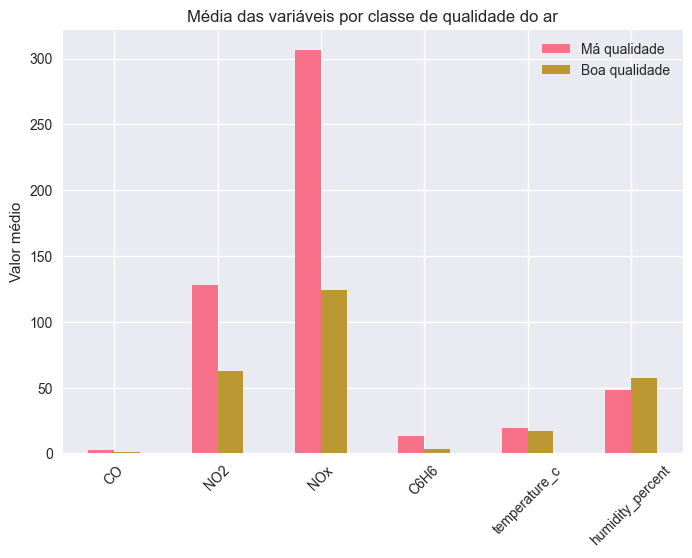

In [112]:
df.groupby('air_quality_good')[['CO','NO2','NOx','C6H6','temperature_c','humidity_percent']].mean().T.plot(kind='bar')

plt.title("Média das variáveis por classe de qualidade do ar")
plt.ylabel("Valor médio")
plt.xticks(rotation=45)
plt.legend(["Má qualidade", "Boa qualidade"])

plt.show()

Os poluentes (NO2, NOx, CO e C6H6) apresentam valores médios significativamente mais elevados em situações de má qualidade do ar, indicando forte associação com episódios de poluição. 

Em contraste, a humidade tende a ser maior quando a qualidade do ar é boa, sugerindo um possível efeito de dispersão dos poluentes. A temperatura apresenta variações menos acentuadas.

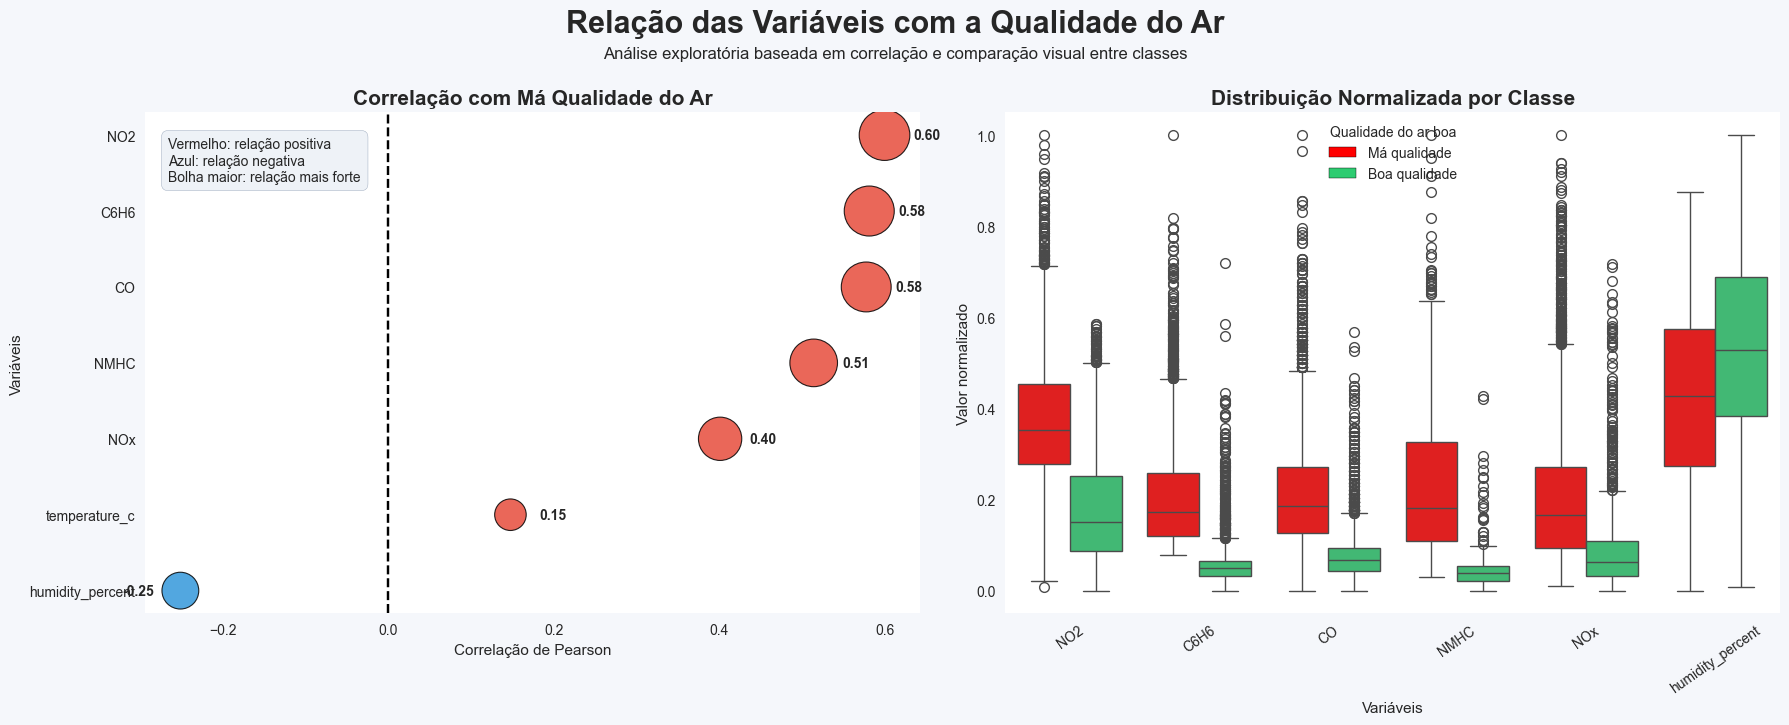

In [ ]:
features = ['NO2', 'NOx', 'CO', 'C6H6', 'NMHC', 'temperature_c', 'humidity_percent']
features = [col for col in features if col in df.columns]

df_eda = df[features + ['air_quality_good']].copy()

# 1 = má qualidade do ar
y_bad = (~df_eda['air_quality_good']).astype(int)

corrs = df_eda[features].corrwith(y_bad).sort_values()

top_features = corrs.abs().sort_values(ascending=False).head(6).index.tolist()

# Normalização min-max por variável, apenas para o gráfico
df_norm = df_eda[top_features + ['air_quality_good']].copy()

for col in top_features:
    df_norm[col] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min())

df_box = df_norm.melt(
    id_vars='air_quality_good',
    var_name='Variável',
    value_name='Valor normalizado'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#f5f7fb')

for ax in axes:
    ax.set_facecolor('white')
    ax.grid(alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

# Gráfico 1 — bolhas
colors_corr = ['#3498db' if v < 0 else '#e74c3c' for v in corrs.values]
sizes = (corrs.abs() * 1800) + 250

axes[0].scatter(
    corrs.values,
    corrs.index,
    s=sizes,
    c=colors_corr,
    alpha=0.85,
    edgecolors='black',
    linewidths=0.8
)

axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('Correlação com Má Qualidade do Ar', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Correlação de Pearson')
axes[0].set_ylabel('Variáveis')

for i, v in enumerate(corrs.values):
    axes[0].text(v + (0.035 if v >= 0 else -0.07), i, f'{v:.2f}', va='center', fontweight='bold')

axes[0].text(
    0.03, 0.95,
    'Vermelho: relação positiva\nAzul: relação negativa\nBolha maior: relação mais forte',
    transform=axes[0].transAxes,
    fontsize=10,
    va='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#eef2f7', edgecolor='#94a3b8')
)

# Gráfico 2 — boxplots normalizados
sns.boxplot(
    data=df_box,
    x='Variável',
    y='Valor normalizado',
    hue='air_quality_good',
    palette={False: "#ff0000", True: '#2ecc71'},
    ax=axes[1]
)
legend_elements = [
    Patch(facecolor='#ff0000', edgecolor='black', label='Má qualidade'),
    Patch(facecolor='#2ecc71', edgecolor='black', label='Boa qualidade')
]
axes[1].set_title('Distribuição Normalizada por Classe', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Variáveis')
axes[1].set_ylabel('Valor normalizado')
axes[1].legend(handles=legend_elements, title='Qualidade do ar boa')
axes[1].tick_params(axis='x', rotation=35)

fig.suptitle(
    'Relação das Variáveis com a Qualidade do Ar',
    fontsize=22,
    fontweight='bold',
    y=1.03
)

fig.text(
    0.5,
    0.96,
    'Análise exploratória baseada em correlação e comparação visual entre classes',
    ha='center',
    fontsize=12
)

plt.tight_layout()
plt.show()

Este gráfico resume a relação entre as variáveis analisadas e a qualidade do ar. À esquerda, apresenta-se a correlação de Pearson entre cada variável e a ocorrência de má qualidade do ar, permitindo identificar quais os fatores mais associados ao aumento ou redução da poluição. À direita, os boxplots mostram a distribuição das variáveis mais relevantes para períodos de boa e má qualidade do ar, após normalização, permitindo uma comparação equilibrada entre variáveis com diferentes escalas.

Observa-se que os poluentes atmosféricos, como NO2, CO, C6H6, NMHC e NOx, apresentam valores mais elevados quando a qualidade do ar é má, indicando uma forte associação com episódios de poluição. Por outro lado, a humidade apresenta valores mais elevados em períodos de boa qualidade do ar, sugerindo um efeito contrário. Esta consistência entre a análise de correlação e a comparação das distribuições reforça a robustez dos resultados obtidos.

## Conclusão Geral

- NOx e NO2 são os principais indicadores de má qualidade do ar
- Existe um padrão sazonal claro (pior no inverno)
- CO apresenta menor variabilidade relativa
- A variável "mês" contribui para a explicação da qualidade do ar
- A separação entre classes sugere boa capacidade preditiva

Estes resultados indicam que é possível construir um modelo eficaz para previsão da qualidade do ar.